In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from vta.utils import CCF, CCFMesh
import k3d

%matplotlib inline
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", font_scale=0.8, rc=custom_params)
%config InlineBackend.figure_format='retina'

%load_ext autoreload
%autoreload 2

In [2]:
df = pd.read_csv("/results/FINAL_manual_proofread_ccf_37brains.csv")
df = df.rename(columns={"x": "ML", "y": "DV", "z": "RC"})

# using an approximate midline value based on the barplot
approx_midline = 230
df["ipsi"] = df["ML"] > 230

display(df.head(3))
print("Unique injection regions", df["injection_region"].unique())
print("Laterality assignment", df["ipsi"].unique())

,brain,channel,injection_region,ML,DV,RC,batch,ipsi
0,746046,561,CTX,261.107788,160.238174,426.496399,final,True
1,746046,561,CTX,260.630951,162.411804,426.451996,final,True
2,746046,561,CTX,260.420593,163.047180,426.273346,final,True


Unique injection regions ['CTX' 'CB' 'SP' 'TH' 'PAG' 'MOB' 'iontoTH']
Laterality assignment [ True False]


In [3]:
# Filter out thalamic pressure injection samples given they might be a mixture of TH and CTX projecting neurons
print(df.shape)
df = df[df["injection_region"] != "TH"]
print(df.shape)

(15876, 8)
(13665, 8)


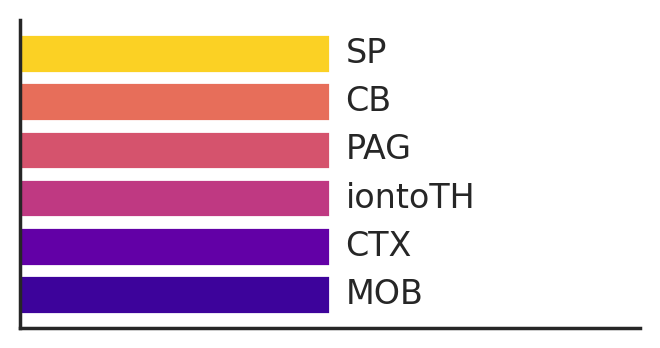

In [4]:
# define color codes for each ROI
cols_hex = ["#3D039B", "#6200A6", "#BF3982", "#D5536D", "#E76E5A", "#FBD124"]
region_col_map = dict(zip(["MOB", "CTX", "iontoTH", "PAG", "CB", "SP"], cols_hex))

fig, ax = plt.subplots(figsize=(4, 2))
for i, (region, color) in enumerate(region_col_map.items()):
    ax.barh(i, 1, color=color)
    ax.text(1.05, i, region, va='center', fontsize=12)
ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(0, 2)
plt.show()

In [5]:
df_ipsi = df[df["ipsi"]]
df_contra = df[df["ipsi"] == False]
order = ["MOB", "CTX", "iontoTH", "PAG", "CB", "SP"]

In [6]:
# get region ids in the CCF (used to get the correct mesh object from /data/ccf_2017_obj/)
ccf = CCF()
regions = ["root", "P-sat", "P-mot"]
region_list = [(k, v) for k, v in ccf.acronymMap.items() if v in regions]
region_idx = [id[0] for id in region_list]
print(region_list)

[(997, 'root'), (987, 'P-mot'), (1117, 'P-sat')]


In [7]:
# manually specify KDE mesh regions and colors
data = {"idx": [997, 987, 1117], "region": ["root", "P-mot", "P-sat"], "color": ["#4d3d3d", "ff6a00", "#fec700"]}
df_ccf = pd.DataFrame(data)

display(df_ccf)

,idx,region,color
0,997,root,#4d3d3d
1,987,P-mot,ff6a00
2,1117,P-sat,#fec700


In [8]:
# add colors for each cell as a column
df["injection_region_color"] = df["injection_region"].map(region_col_map)

In [9]:
# Plot all cells colored by injection region with transparency setting and amenable to on/off display toggling
# Initialize k3d plot
plot = k3d.plot(camera_zoom_speed=10, camera_fov=30.0)

# Group data by injection_region_color
grouped = df.groupby("injection_region_color")

# Add points (cells) for each group
for color, group in grouped:
    pos = group[["RC", "DV", "ML"]].values.astype(np.float32) * ccf.resolution
    cols = np.array([int(color.replace("#", ""), 16)] * len(group), dtype=np.uint32)
    injection_target_name = group["injection_region"].iloc[
        0
    ]  # Assuming all rows in the group have the same injection_target

    plt_points = k3d.points(
        positions=pos, point_size=25, shader="3d", colors=cols, opacity=0.6, name=injection_target_name
    )
    plot += plt_points

# Add region meshes
for idx in df_ccf["idx"]:
    vertices, normals, indices = CCFMesh.get_mesh_from_id(idx)
    col = int(df_ccf["color"][df_ccf["idx"] == idx].values[0].replace("#", "0x"), 16)

    plt_mesh = k3d.mesh(vertices, indices, normals=normals, color=col, wireframe=False, opacity=0.1)
    plot += plt_mesh

# Display plot
plot.display()

# Save as interactive HTML
html_path = "/results/plots/somata_3d_all_regions_CCFmeshes.html"
with open(html_path, "w") as f:
    f.write(plot.get_snapshot())
print(f"Saved: {html_path}")

Output()

Saved: /results/plots/somata_3d_all_regions_CCFmeshes.html


In [10]:
def plot_cells_by_roi(df, injection_region, ccf, k3d, color_map, df_ccf=None, add_meshes=False, save_html=False):
    plot = k3d.plot(camera_zoom_speed=10, camera_fov=30.0)
    filtered_df = df[df["injection_region"] == injection_region]
    grouped = filtered_df.groupby("brain")
    unique_brains = list(grouped.groups.keys())
    brain_to_color = {brain: color_map[i % len(color_map)] for i, brain in enumerate(unique_brains)}
    for brain, group in grouped:
        pos = group[["RC", "DV", "ML"]].values.astype(np.float32) * ccf.resolution
        cols = np.array([brain_to_color[brain]] * len(group), dtype=np.uint32)
        plt_points = k3d.points(
            positions=pos, point_size=25, shader="3d", colors=cols, opacity=0.6, name=str(brain)
        )
        plot += plt_points
    if add_meshes and df_ccf is not None:
        for idx in df_ccf["idx"]:
            try:
                vertices, normals, indices = CCFMesh.get_mesh_from_id(idx)
                col = int(df_ccf["color"][df_ccf["idx"] == idx].values[0].replace("#", "0x"), 16)
                plt_mesh = k3d.mesh(vertices, indices, normals=normals, color=col, wireframe=False, opacity=0.1)
                plot += plt_mesh
            except FileNotFoundError:
                print(f"Mesh file for region {idx} not found, skipping.")
    plot.display()

    if save_html:
        html_path = f"/results/plots/somata_3d_{injection_region}.html"
        with open(html_path, "w") as f:
            f.write(plot.get_snapshot())
        print(f"Saved: {html_path}")

In [11]:
color_map = {0: 0x00FFFF, 1: 0xFF00FF, 2: 0xFFA500, 3: 0x800080, 4: 0x7CFC00, 5: 0xDC143C, 6: 0x008080, 7:0x808080}
plot_cells_by_roi(df, "MOB", ccf, k3d, color_map, df_ccf, save_html=True)

Output()

Saved: /results/plots/somata_3d_MOB.html


In [12]:
plot_cells_by_roi(df, "CTX", ccf, k3d, color_map, df_ccf, save_html=True)

Output()

Saved: /results/plots/somata_3d_CTX.html


In [13]:
plot_cells_by_roi(df, "iontoTH", ccf, k3d, color_map, df_ccf, save_html=True)

Output()

Saved: /results/plots/somata_3d_iontoTH.html


In [14]:
plot_cells_by_roi(df, "PAG", ccf, k3d, color_map, df_ccf, save_html=True)

Output()

Saved: /results/plots/somata_3d_PAG.html


In [15]:
plot_cells_by_roi(df, "CB", ccf, k3d, color_map, df_ccf, save_html=True)

Output()

Saved: /results/plots/somata_3d_CB.html


In [16]:
plot_cells_by_roi(df, "SP", ccf, k3d, color_map, df_ccf, save_html=True)

Output()

Saved: /results/plots/somata_3d_SP.html
